In [ ]:
import pybliometrics
from pybliometrics.scopus import  ScopusSearch
from pybliometrics.scopus import AffiliationSearch
import pandas as pd
pybliometrics.init()
pybliometrics.scopus.init()

In [7]:
from pybliometrics.scopus import AbstractRetrieval

search = ScopusSearch('AFFIL("West Virginia University") AND TITLE-ABS-KEY("machine learning" OR "artificial intelligence") AND PUBYEAR > 2018', refresh=True)
import time
import pandas as pd

eids = search.get_eids()  # list of EIDs from the search



rows = []

for eid in eids:
    try:
        ab = AbstractRetrieval(eid, view="FULL")

        funding = getattr(ab, "funding", [])
        funding_text = getattr(ab, "funding_text", "")
        grant_numbers = getattr(ab, "grant_numbers", [])
        funding_ids = getattr(ab, "funding_ids", [])

        rows.append({
            "eid": eid,
            "title": ab.title,
            "funding": "; ".join(funding) if funding else "",
            "funding_text": funding_text,
            "grant_numbers": "; ".join(grant_numbers) if grant_numbers else "",
            "funding_ids": "; ".join(funding_ids) if funding_ids else "",
        })

    except Exception as e:
        print(f"❌ Failed on {eid}: {e}")

    time.sleep(0.2)


funding_df = pd.DataFrame(rows)
funding_df.to_csv("wvu_ml_funding_scopus.csv", index=False)
print("Saved funding data to wvu_ml_funding_scopus.csv")


❌ Failed on 2-s2.0-105016515789: sequence item 0: expected str instance, Funding found
❌ Failed on 2-s2.0-105016089728: sequence item 0: expected str instance, Funding found
❌ Failed on 2-s2.0-85218126600: sequence item 0: expected str instance, Funding found
❌ Failed on 2-s2.0-105019505878: sequence item 0: expected str instance, Funding found
❌ Failed on 2-s2.0-105018306119: sequence item 0: expected str instance, Funding found
❌ Failed on 2-s2.0-105015771988: sequence item 0: expected str instance, Funding found
❌ Failed on 2-s2.0-105013276708: sequence item 0: expected str instance, Funding found
❌ Failed on 2-s2.0-105006921885: sequence item 0: expected str instance, Funding found
❌ Failed on 2-s2.0-105003196350: sequence item 0: expected str instance, Funding found
❌ Failed on 2-s2.0-105002976318: sequence item 0: expected str instance, Funding found
❌ Failed on 2-s2.0-105002645154: sequence item 0: expected str instance, Funding found
❌ Failed on 2-s2.0-105022927647: sequence it

In [4]:
from pybliometrics.scopus import AffiliationSearch

query1 = "AFFIL(West Virginia University)"
s = AffiliationSearch(query1)
s.affiliations
df1 = pd.DataFrame(s.affiliations)
df1[df1['city'] == 'Morgantown']

,eid,name,variant,documents,city,country
0,10-s2.0-60021143,West Virginia University,,57199,Morgantown,United States
1,10-s2.0-60022783,West Virginia University School of Medicine Mo...,,13735,Morgantown,United States
5,10-s2.0-60022445,West Virginia University School of Nursing,,473,Morgantown,United States
6,10-s2.0-60020890,West Virginia University School of Dentistry,,465,Morgantown,United States
7,10-s2.0-60019423,West Virginia University Hospitals Incorporated,,390,Morgantown,United States
8,10-s2.0-60013489,West Virginia University Extension Service,WVU Extension Service,165,Morgantown,United States
10,10-s2.0-60274189,West Virginia University Health System,,36,Morgantown,United States
11,10-s2.0-60008925,University of West Virginia Medical Center,,24,Morgantown,United States
12,10-s2.0-122626324,West Virginia University Medicine Children's H...,,9,Morgantown,United States
21,10-s2.0-130880667,West Virginia University Division of Plastic S...,West Virginia University Division Of Plastic S...,1,Morgantown,United States


In [18]:
wvu_faculty = pd.read_excel("/home/kehinde/Elsevier/Faculty_TT_Ten_July_2025.xlsx")
wvu_faculty["Full Name"]

0      Panaccione, Daniel G
1              Hagan, Joe D
2            Kao, Elizabeth
3              Ryan, Sharon
4        DiSalvo, Charles R
               ...         
875          Edwards, Jerry
876        Bascom, Benjamin
877              Liu, Shian
878     Mishra, Anand Kumar
879            Young, Sarah
Name: Full Name, Length: 880, dtype: object

Papers with ML, Deep Learning, AI, or NN in abstract

In [8]:
query = (
    'AFFIL("West Virginia University") AND ''TITLE-ABS-KEY("Machine Learning" OR "deep learning" OR "artificial intelligence" OR "neural network")'
)
search = ScopusSearch(query, view="COMPLETE")

print("Number of results:", search.get_results_size())
df = pd.DataFrame(search.results)

filtered_df = df
print(filtered_df[['authkeywords','fund_no','fund_acr', 'description','author_names']].nunique())


filtered_df

Number of results: 1660
authkeywords    1088
fund_no          426
fund_acr         153
description     1586
author_names    1508
dtype: int64


,eid,doi,pii,pubmed_id,title,subtype,subtypeDescription,creator,afid,affilname,...,pageRange,description,authkeywords,citedby_count,openaccess,freetoread,freetoreadLabel,fund_acr,fund_no,fund_sponsor
0,2-s2.0-105016515789,10.1016/j.fuel.2025.136795,S0016236125025207,None,Development of a hybrid first principles-machi...,ar,Article,Saini V.,60157687;60006272;100361038,Benjamin M. Statler College of Engineering and...,...,None,A framework for health monitoring of high-temp...,Coal-fired plant | First principles | Hybrid g...,1,0,None,None,ERDA,DE-FE0031768,U.S. Department of Energy
1,2-s2.0-105020241845,10.1007/978-3-032-08009-7_22,None,None,Effect of Data Augmentation on Conformal Predi...,cp,Conference Paper,Ahamed R.,60015875;60021143,University of Aberdeen;West Virginia University,...,223-232,The clinical deployment of deep learning model...,Conformal Prediction | Data Augmentation | Dia...,0,0,None,None,None,None,None
2,2-s2.0-105018080056,10.1007/978-3-032-05127-1_34,None,None,NERO: Explainable Out-of-Distribution Detectio...,cp,Conference Paper,Chhetri A.,60015875;60021143;125314061,University of Aberdeen;West Virginia Universit...,...,349-359,Ensuring reliability is paramount in deep lear...,Explainable | Gastrointestinal imaging | Neuro...,0,0,None,None,None,None,None
3,2-s2.0-105016089728,10.1016/j.compchemeng.2025.109392,S0098135425003953,None,Application of unsupervised machine learning m...,ar,Article,Beahr D.,60157687,Benjamin M. Statler College of Engineering and...,...,None,A fundamental obstacle to the implementation o...,Gaussian mixture model | Machine learning | Pr...,0,0,None,None,WVU,DE-FE0025912,West Virginia University
4,2-s2.0-105011747829,10.1007/978-3-031-98691-8_14,None,None,Out-of-Distribution Detection in Gastrointesti...,cp,Conference Paper,Pokhrel S.,60022148;60012070;60020661;60015875;60000239;6...,University College London;University of Leeds;...,...,190-200,The integration of deep learning tools in gast...,Feature Centroid | Gastrointestinal Disease | ...,0,0,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1655,2-s2.0-0024079239,10.1109/28.8992,None,None,Knowledge Organization and Inference Engine fo...,ar,Article,Reddy N.A.,60027271;60021143;60157687;100987247,U.S. Naval Research Laboratory;West Virginia U...,...,866-869,The knowledge-based organization for the West ...,None,0,0,None,None,WVU,None,West Virginia University
1656,2-s2.0-0024078759,10.1109/28.8991,None,None,A Production System for Intelligent Monitoring...,ar,Article,Raman R.S.,60021143;60157687,West Virginia University;Benjamin M. Statler C...,...,862-865,Monitoring systems provide information about v...,None,9,0,None,None,None,None,None
1657,2-s2.0-0023331186,10.1177/003754978704800408,None,None,Epistemology of knowledge based simulation,ar,Article,Reddy R.,60006320,MIT Computer Science & Artificial Intelligence...,...,162-166,Combining artificial intelligence concepts wit...,automation of analysis | decision support | in...,47,0,None,None,None,None,None
1658,2-s2.0-0022583151,10.1109/TIA.1986.4504688,None,None,"An Expert System Design for Ventilation, Emerg...",ar,Article,Nutter R.S.,60021143;60157687,West Virginia University;Benjamin M. Statler C...,...,97-101,The development of a rudimentary expert system...,None,4,0,None,None,None,None,None


In [32]:
OUTFILE = "/home/kehinde/Elsevier/WVU_ML_AI_DL_DeepLearning_Scopus_2025.csv"
filtered_df.to_csv(OUTFILE, index=False)

In [9]:
filtered_df.columns

Index(['eid', 'doi', 'pii', 'pubmed_id', 'title', 'subtype',
       'subtypeDescription', 'creator', 'afid', 'affilname',
       'affiliation_city', 'affiliation_country', 'author_count',
       'author_names', 'author_ids', 'author_afids', 'coverDate',
       'coverDisplayDate', 'publicationName', 'issn', 'source_id', 'eIssn',
       'aggregationType', 'volume', 'issueIdentifier', 'article_number',
       'pageRange', 'description', 'authkeywords', 'citedby_count',
       'openaccess', 'freetoread', 'freetoreadLabel', 'fund_acr', 'fund_no',
       'fund_sponsor'],
      dtype='object')

In [10]:
filtered_df[['authkeywords','fund_no','fund_acr', 'description','author_names']].head(30)

,authkeywords,fund_no,fund_acr,description,author_names
0,Coal-fired plant | First principles | Hybrid g...,DE-FE0031768,ERDA,A framework for health monitoring of high-temp...,"Saini, Vivek;Purdy, Daniel;Mukherjee, Angan;Ad..."
1,Conformal Prediction | Data Augmentation | Dia...,None,None,The clinical deployment of deep learning model...,"Ahamed, Rizwan;Amireskandari, Annahita;Palko, ..."
2,Explainable | Gastrointestinal imaging | Neuro...,None,None,Ensuring reliability is paramount in deep lear...,"Chhetri, Anju;Korhonen, Jari;Gyawali, Prashnna..."
3,Gaussian mixture model | Machine learning | Pr...,DE-FE0025912,WVU,A fundamental obstacle to the implementation o...,"Beahr, Daniel;Bhattacharyya, Debangsu"
4,Feature Centroid | Gastrointestinal Disease | ...,None,None,The integration of deep learning tools in gast...,"Pokhrel, Sandesh;Bhandari, Sanjay;Ali, Sharib;..."
5,artificial intelligence (AI) | classification ...,None,None,Background: Pneumonia is a leading cause of gl...,"Katreddi, Sasanka;Midatani, Avinash;Roy, Aksha..."
6,Adversarial attack | Cyber-security | Deep lea...,IITP-2025-RS-2020-II201612,NRF,Deep learning-based intrusion detection system...,"Izuazu, Urslla Uchechi;Nwakanma, Cosmas Ifeany..."
7,Arrhythmia | Artificial Intelligence | Atrial ...,None,None,Purpose of Review: This review provides compre...,"Agarwal, Manyoo A.;Sridharan, Aadhavi;Pham, Ho..."
8,Deep learning | Drug-drug interaction | Protie...,None,None,Adverse drug events represent a key challenge ...,"Islam, Saminur;Abbasi, Ahmed;Agarwal, Nitin;Zh..."
9,Data-driven prognosis | Machine learning | Pat...,None,None,Identifying meaningful patient phenotypes is a...,"Amiri Shahbazi, Marzieh;Al-Mamun, Mohammad Abd..."


In [11]:
filtered_df[filtered_df["author_names"].str.contains("Aldo", na=False)]

,eid,doi,pii,pubmed_id,title,subtype,subtypeDescription,creator,afid,affilname,...,pageRange,description,authkeywords,citedby_count,openaccess,freetoread,freetoreadLabel,fund_acr,fund_no,fund_sponsor
24,2-s2.0-105020254524,10.1063/5.0288278,None,41159866,Abinit 2025: New capabilities for the predicti...,ar,Article,Verstraete M.J.,60106017;60007989;60009507;60119141;60028186;6...,Université Paris-Saclay;Universiteit Utrecht;U...,...,None,Abinit is a widely used scientific software pa...,None,0,0,None,None,None,None,None
194,2-s2.0-85192277941,10.1038/s41524-024-01259-w,None,None,JARVIS-Leaderboard: a large scale benchmark of...,ar,Article,Choudhary K.,60016849;60029278;60003269;60010261;60024266;6...,University of Toronto;The University of Chicag...,...,None,Lack of rigorous reproducibility and validatio...,None,26,1,all publisherfullgold repository repositoryam,All Open Access Gold Green,NNSA,2053929,National Nuclear Security Administration
195,2-s2.0-85191821387,10.1038/s41598-024-54655-z,None,38565852,AI is a viable alternative to high throughput ...,ar,Article,Wallach I.,60025778;60008088;60015481;60025038;60012708;6...,"University of Michigan, Ann Arbor;Universidade...",...,None,High throughput screening (HTS) is routinely u...,None,63,1,all publisherfullgold repository repositoryam ...,All Open Access Gold Green,JSPS,19K05818,Japan Society for the Promotion of Science
203,2-s2.0-85205266195,10.1016/j.mtphys.2024.101560,S2542529324002360,None,Improving machine-learning models in materials...,ar,Article,Schmidt J.,60025858;60005322;60021143;60208597,ETH Zürich;Ruhr-Universitat Bochum;West Virgin...,...,None,The accuracy of a machine learning model is li...,None,41,1,all publisherhybridgold repository repositoryvor,All Open Access Hybrid Gold Green,LRZ,101073486,Leibniz-Rechenzentrum
248,2-s2.0-85200336748,10.1039/d4cp01196a,None,39082370,Exploring flat-band properties in two-dimensio...,ar,Article,Wang H.C.,60005322;60029507;60021143;60072562,Ruhr-Universitat Bochum;Friedrich-Schiller-Uni...,...,21558-21567,We present a computational study of the M<inf>...,None,2,1,all publisherhybridgold repository repositoryam,All Open Access Hybrid Gold Green,FNR,2137603,Fonds National de la Recherche Luxembourg
316,2-s2.0-85207192848,10.3389/fmats.2024.1474609,None,None,Enhancing material property prediction with en...,ar,Article,Rahman C.M.A.,60021143;60157687,West Virginia University;Benjamin M. Statler C...,...,None,Machine learning (ML) models have emerged as p...,ensemble model | graph neural networks | mater...,6,1,all publisherfullgold,All Open Access Gold,WVHEPC,1650474,West Virginia Higher Education Policy Commission
396,2-s2.0-85177744295,10.1016/j.forsciint.2023.111884,S0379073823003341,37989070,Using convolutional neural networks to support...,ar,Article,Lang L.,60021143;60026097,West Virginia University;Battelle,...,None,This paper describes the construction and use ...,Convolutional neural networks | Decision tree ...,0,0,None,None,NSF,MRI-2117575,National Science Foundation
448,2-s2.0-85158871462,10.1088/2053-1583/accc43,None,None,Symmetry-based computational search for novel ...,ar,Article,Wang H.C.,60021143;60014059;60072562,West Virginia University;Martin-Luther-Univers...,...,None,We present a symmetry-based systematic approac...,2D materials | 2D materials database | density...,13,1,all publisherhybridgold repository repositoryam,All Open Access Hybrid Gold Green,LRZ,ACI-1053575,Leibniz-Rechenzentrum
583,2-s2.0-85145025425,10.1038/s41598-022-26729-3,None,36577763,Vickers hardness prediction from machine learn...,ar,Article,Dovale-Farelo V.,60021143;60024830,West Virginia University;Benemérita Universida...,...,None,The search for new superhard materials is of g...,None,20,1,all publisherfullgold repository repositoryam,All Open Access Gold Green,USDOE,ACI-1053575,U.S. Department of Energy
701,2-s2.0-85121148543,10.1016/j.cplett.2021.139283,S0009261421009660,None,Implementing machine learning for the identifi...,ar,Ar

In [12]:
filtered_df["author_names"]

0       Saini, Vivek;Purdy, Daniel;Mukherjee, Angan;Ad...
1       Ahamed, Rizwan;Amireskandari, Annahita;Palko, ...
2       Chhetri, Anju;Korhonen, Jari;Gyawali, Prashnna...
3                   Beahr, Daniel;Bhattacharyya, Debangsu
4       Pokhrel, Sandesh;Bhandari, Sanjay;Ali, Sharib;...
                              ...                        
1655                                   Reddy, Narendar A.
1656                          Raman, Ravi S.;Reddy, Y. V.
1657                                        Reddy, Ramana
1658    Nutter, Roy S.;Reddy, Y. V.;Atkins, John M.;Ra...
1659                                       Rine, David C.
Name: author_names, Length: 1660, dtype: object

In [13]:
# Split by semicolon and strip whitespace
filtered_df["author_names"] = (
    filtered_df["author_names"]
    .astype(str)
    .str.split(";")
    .apply(lambda lst: [a.strip() for a in lst if a.strip()])
)

filtered_df["author_names"]

0       [Saini, Vivek, Purdy, Daniel, Mukherjee, Angan...
1       [Ahamed, Rizwan, Amireskandari, Annahita, Palk...
2       [Chhetri, Anju, Korhonen, Jari, Gyawali, Prash...
3                [Beahr, Daniel, Bhattacharyya, Debangsu]
4       [Pokhrel, Sandesh, Bhandari, Sanjay, Ali, Shar...
                              ...                        
1655                                 [Reddy, Narendar A.]
1656                       [Raman, Ravi S., Reddy, Y. V.]
1657                                      [Reddy, Ramana]
1658    [Nutter, Roy S., Reddy, Y. V., Atkins, John M....
1659                                     [Rine, David C.]
Name: author_names, Length: 1660, dtype: object

In [11]:
# filtered_df.loc[:, "author_names"] = (
#     filtered_df["author_names"]
#         .fillna("")
#         .astype(str)
#         .str.split(";")
#         .apply(lambda lst: [a.strip() for a in lst if a.strip()])
# )
# filtered_df["author_names"]

# filtered_df[
#    filtered_df["author_names"].apply(
#         lambda lst: any("Mandal" in a or "mandal" in a.lower() for a in lst)
#     )
# ]["author_names"]



In [20]:
import re

def normalize_tokens(name):
    """Split a name into lowercase tokens (words)."""
    if not isinstance(name, str):
        return set()
    tokens = re.split(r"[,\s;\.\-]+", name.strip())
    return {t.lower() for t in tokens if t}
    

# Create token sets for each WVU faculty name
faculty_token_sets = [
    normalize_tokens(name)
    for name in wvu_faculty["Full Name"].dropna()
]

def author_matches_faculty(author):
    """Return True if this author matches ANY faculty name (≥2 tokens equal)."""
    tokens = normalize_tokens(author)
    if not tokens:
        return False
    
    for fac_tokens in faculty_token_sets:
        if len(tokens & fac_tokens) >= 2:
            return True
    return False
def row_has_wvu_faculty(authors):
    """Authors is a list, return True if any individual author matches faculty."""
    if not isinstance(authors, list):
        return False
    return any(author_matches_faculty(a) for a in authors)


In [21]:
faculty_list = [
    (name, normalize_tokens(name))
    for name in wvu_faculty["Full Name"].dropna()
]
def matched_faculty_for_author(author):
    tokens = normalize_tokens(author)
    if not tokens:
        return []
    
    matches = []
    for fac_name, fac_tokens in faculty_list:
        if len(tokens & fac_tokens) >= 2:
            matches.append(fac_name)
    return matches
def row_matching_faculty(authors):
    if not isinstance(authors, list):
        return []
    
    matched = []
    for a in authors:
        matched.extend(matched_faculty_for_author(a))
    
    # Remove duplicates
    return list(set(matched))


In [22]:
filtered_df["matched_faculty"] = filtered_df["author_names"].apply(row_matching_faculty)
filtered_df["has_wvu_faculty"] = filtered_df["matched_faculty"].apply(lambda x: len(x) > 0)
unique_faculty = set().union(*filtered_df["matched_faculty"])
print(len(unique_faculty))
sorted(unique_faculty)


246


['Abdul Aziz, Omar I',
 'Aburahma, Ali F',
 'Adjeroh, Donald Asogu',
 'Ahmed, Imtiaz',
 'Al-Mamun, Mohammad Abdulla',
 'AlAqqad, Waseem Qadri Abd Alrahi',
 'Aluri, Ajay Kumar',
 'Ameri, Samuel',
 'Amin, Md Nurul',
 'Aminian, Kashy',
 'Anderson, Charles T',
 'Anderson, Karen G',
 'Anderson, Loren Dean',
 'Arroyo, Luis Eduardo',
 'Ashwell, Christopher M',
 'Avci, Onur',
 'Bagby, Michael D',
 'Ballentine, Brian D',
 'Bandura, Kevin Michael',
 'Barbero, Ever J',
 'Barrett, James J',
 'Benison, Kathleen Counter',
 'Bennewitz, Margaret Frances',
 'Bhattacharyya, Debangsu',
 'Bilitsky, Christopher J',
 'Bolyard, Johnna J',
 'Boone, Brian Anthony',
 'Bora, Siddhartha S',
 'Bowdridge, Elizabeth Compton',
 'Brigandi, Carla Belanger',
 'Brown, Patrick Jeremy',
 'Brzostek, Edward Robert',
 'Burns, Robert C',
 'Butler, Peter Mac Iver',
 'Cain, Stephen Matthew',
 'Carpenter, Roger D',
 'Carter-Templeton, Heather Dawn',
 'Cassak, Paul A',
 'Cerbone, David R',
 'Chakraborty, Somenath',
 'Chantler, Pau

In [36]:
filtered_df["has_wvu_faculty"] = filtered_df["author_names"].apply(row_has_wvu_faculty)
matches_df = filtered_df[filtered_df["has_wvu_faculty"]]
matches_df["fund_acr"].isnull().sum()


np.int64(324)

In [ ]:
#mask = matches_df["fund_no"].astype(str).str.contains("1726534", na=False)
mask_dolly = matches_df.astype(str).apply(lambda col: col.str.contains("1726534", na=False)).any(axis=1)

len(matches_df[mask_dolly])


6

In [26]:
# mask_dolly = matches_df["fund_no"].astype(str).str.contains("2117575", na=False)
mask_dolly = matches_df.astype(str).apply(lambda col: col.str.contains("2117575", na=False)).any(axis=1)
len(matches_df[mask_dolly])


2

In [16]:
from agapi.client import Agapi

from openai import OpenAI

# model_name="deepseek-ai/deepseek-v3.1"
# model_name="google/gemma-3-27b-it"
# model_name="moonshotai/kimi-k2-instruct-0905"
# model_name="meta/llama-3.2-90b-vision-instruct"
# model_name="meta/llama-4-maverick-17b-128e-instruct"
# model_name = "openai/gpt-oss-20b"
# model_name="openai/gpt-oss-120b"
# model_name="qwen/qwen3-next-80b-a3b-instruct"

model_name = "openai/gpt-oss-20b"
api_key="sk-a70a04690a60449c8720138aca1c0eab"

client = OpenAI(
    base_url="https://atomgpt.org/api",
    api_key=api_key
)

result = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": '''Give just a topic to this abstract based on the ML tool used in two or one word : A framework for health monitoring of high-temperature boiler components has been developed using a hybrid grey box modeling technique that combines first-principles white box (WB) models with machine learning black box (BB) models. The WB model is a dynamic, distributed 3-D differential–algebraic equation model that includes detailed heat-transfer mechanisms across metal tube walls, while the BB model is a static-dynamic neural network model or a Bayesian machine learning model. Two hybrid grey box model structures are developed for modeling temporal and spatial variation in the main steam outlet temperature from the final superheater of a pulverized coal-fired boiler. An adaptive fading-memory-based training algorithm for the BB models is developed to address the build-up of model error with time while keeping the volume of data for training BB models constant. The framework is rigorously tested using data collected from a power plant under load-following operations. A key focus of this work is on the prediction of oxide scale growth, a significant damage mechanism in superheater tubing, using a parabolic growth law. Model predictions are compared against plant data for oxide scale measurements from tube specimens that were installed in a coal-fired boiler superheater for 22 months. The framework can be useful "
        for more efficient maintenance planning, cost reduction, and enhancing power plants reliability and safety.'''}
    ],
    reasoning_effort="high"
)

print(result.choices[0].message.content)


Neural Networks


In [ ]:
import time

def get_topic(text):
    """Send a single abstract to the model and return the topic."""
    if not isinstance(text, str) or not text.strip():
        return ""

    try:
        resp = client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user",
                 "content": (
                     '''Give just a topic to this abstract based on the ML tool used in two or one word : '''
                     f"{text}"
                 )
                }
            ],
            reasoning_effort="high"
        )
        return resp.choices[0].message.content.strip()
    except Exception as e:
        print("Error:", e)
        return ""

# ---- Loop through description column safely ----
topics = []

for desc in matches_df["description"]:
    topic = get_topic(desc)
    topics.append(topic)
    time.sleep(0.3)  # small delay to avoid rate limits

matches_df["topic"] = topics

matches_df[["description", "topic"]].head(20)


/tmp/ipykernel_5670/127902302.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_df["topic"] = topics


,description,topic
0,A framework for health monitoring of high-temp...,Bayesian Neural Networks
1,The clinical deployment of deep learning model...,Conformal Prediction
2,Ensuring reliability is paramount in deep lear...,Neuron Relevance
3,A fundamental obstacle to the implementation o...,GMM‑RL
4,The integration of deep learning tools in gast...,NCDD
8,Adverse drug events represent a key challenge ...,PS3N
9,Identifying meaningful patient phenotypes is a...,Hybrid Clustering
10,Background: Flavor prediction—the computationa...,Flavor GNN
13,This work develops an explicit machine learnin...,Explicit ML‑MPC
14,This study introduces Glucose Level Understand...,Offline RL


In [ ]:
matches_df["generated_topic"].value_counts()

generated_topic
Neural Networks             36
Random Forest               35
Deep Learning               34
Neural Network              25
Machine Learning            21
                            ..
Shapiro‑Wilk                 1
Segment Anything             1
Hybrid Hardware‑Software     1
Dataless Neural Networks     1
ChatGPT Bibliometrics        1
Name: count, Length: 486, dtype: int64

In [ ]:
matches_df["generated_topic"] = (
    matches_df["generated_topic"]
        .astype(str)
        .str.replace(r"[^A-Za-z\s]", "", regex=True)
        .str.strip()
)


/tmp/ipykernel_278883/1271413517.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_df["generated_topic"] = (


In [ ]:
matches_df["generated_topic"].head(50)
topic_count = matches_df["generated_topic"].value_counts()
topic_count

generated_topic
Neural Networks             37
Deep Learning               36
Random Forest               35
Neural Network              25
Machine Learning            21
                            ..
Dataless Neural Networks     1
Loss Reweighting             1
Feature Normalization        1
Ensemble CGCNN               1
Residual CNN                 1
Name: count, Length: 477, dtype: int64

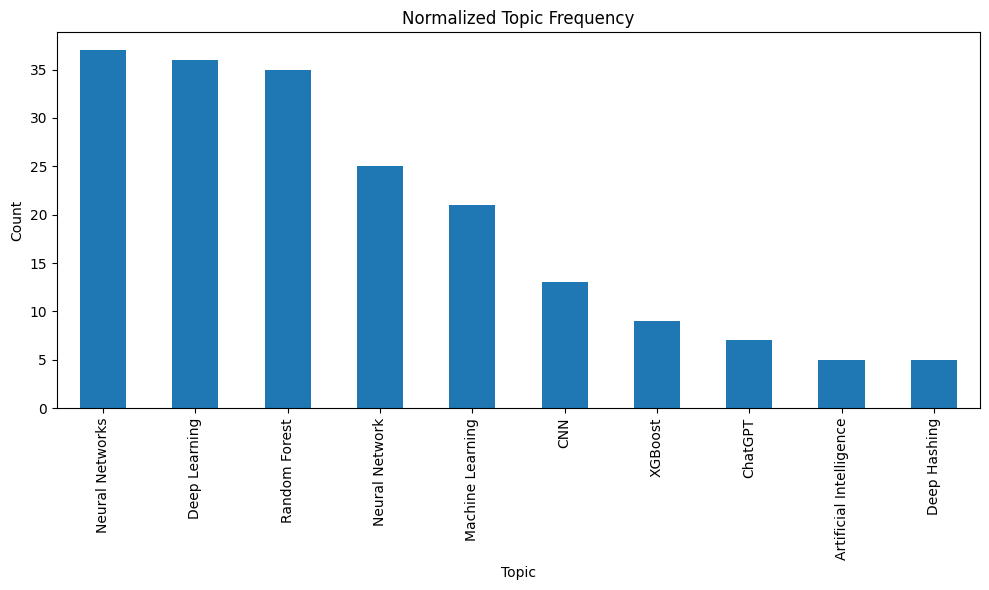

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
topic_count[:10].plot(kind="bar")
plt.title("Normalized Topic Frequency")
plt.ylabel("Count")
plt.xlabel("Topic")
plt.tight_layout()
plt.show()

In [ ]:
TOPIC_NORMALIZE = {
    # Neural networks
    "neural network": ("Neural Network", "Neural Methods"),
    "NeuralNetworks": ("Neural Network", "Neural Methods"),
    "Neural networks": ("Neural Network", "Neural Methods"),
    "Networks": ("Neural Network", "Neural Methods"),
    "ann": ("Neural Network", "Neural Methods"),
    "dnn": ("Neural Network", "Neural Methods"),
    "deep learning": ("Neural Network", "Neural Methods"),
    "cnn": ("Neural Network", "Neural Methods"),
    "rnn": ("Neural Network", "Neural Methods"),
    "lstm": ("Neural Network", "Neural Methods"),
    "mlp": ("Neural Network", "Neural Methods"),
    

    # Bayesian
    "bayesian": ("Bayesian ML", "Bayesian Methods"),
    "bayesian ml": ("Bayesian ML", "Bayesian Methods"),
    "bayesian model": ("Bayesian ML", "Bayesian Methods"),
    "gaussian process": ("Bayesian ML", "Bayesian Methods"),
    "bayesian network": ("Bayesian ML", "Bayesian Methods"),

    # SVM
    "svm": ("SVM", "Kernel Methods"),
    "support vector machine": ("SVM", "Kernel Methods"),
    "support vector": ("SVM", "Kernel Methods"),

    # Tree & Ensemble
    "decision tree": ("Decision Tree", "Tree Ensemble"),
    "random forest": ("Random Forest", "Tree / Ensemble"),
    "xgboost": ("Boosting", "Tree / Ensemble"),
    "gradient boosting": ("Boosting", "Tree / Ensemble"),
    "gbm": ("Boosting", "Tree / Ensemble"),

    # Reinforcement Learning
    "reinforcement learning": ("Reinforcement Learning", "Reinforcement Learning"),
    "rl": ("Reinforcement Learning", "Reinforcement Learning"),

    # Clustering / Unsupervised
    "k-means": ("Clustering", "Unsupervised"),
    "kmeans": ("Clustering", "Unsupervised"),
    "clustering": ("Clustering", "Unsupervised"),

    # WTA
    "winner take all": ("WTA Network", "Neural Methods"),
    "winner-take-all": ("WTA Network", "Neural Methods"),
    "wta": ("WTA Network", "Neural Methods"),

    # Expert / Rule-Based
    "expert system": ("Expert System", "Rule-Based / Expert"),
    "rule-based": ("Expert System", "Rule-Based / Expert"),

    # Hybrid
    "grey box": ("Grey Box Model", "Hybrid / Grey-Box"),
    "gray box": ("Grey Box Model", "Hybrid / Grey-Box"),
    "hybrid model": ("Hybrid Model", "Hybrid / Grey-Box"),

    # Statistical / Regression
    "regression": ("Regression", "Statistical"),
    "statistical": ("Statistical Model", "Statistical"),
}



In [ ]:
def normalize_topic(raw_topic):
    if not isinstance(raw_topic, str):
        return (" ", "")

    t = raw_topic.lower().strip()

    # direct match
    if t in TOPIC_NORMALIZE:
        return TOPIC_NORMALIZE[t]

    # partial match
    for key in TOPIC_NORMALIZE:
        if key in t:
            return TOPIC_NORMALIZE[key]
    
    return (raw_topic.strip())



In [ ]:
matches_df[["topic_norm", "topic_category"]] = (
    matches_df["generated_topic"]
    .apply(normalize_topic)
    .apply(pd.Series)
)


/tmp/ipykernel_278883/3362265616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_df[["topic_norm", "topic_category"]] = (
/tmp/ipykernel_278883/3362265616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_df[["topic_norm", "topic_category"]] = (


In [ ]:
topic_counts = matches_df["topic_norm"].value_counts()
topic_counts[:10]


topic_norm
Neural Network             192
Random Forest               36
Machine Learning            21
Boosting                    17
SVM                         16
Regression                  10
Clustering                   9
Reinforcement Learning       8
ChatGPT                      7
Artificial Intelligence      5
Name: count, dtype: int64

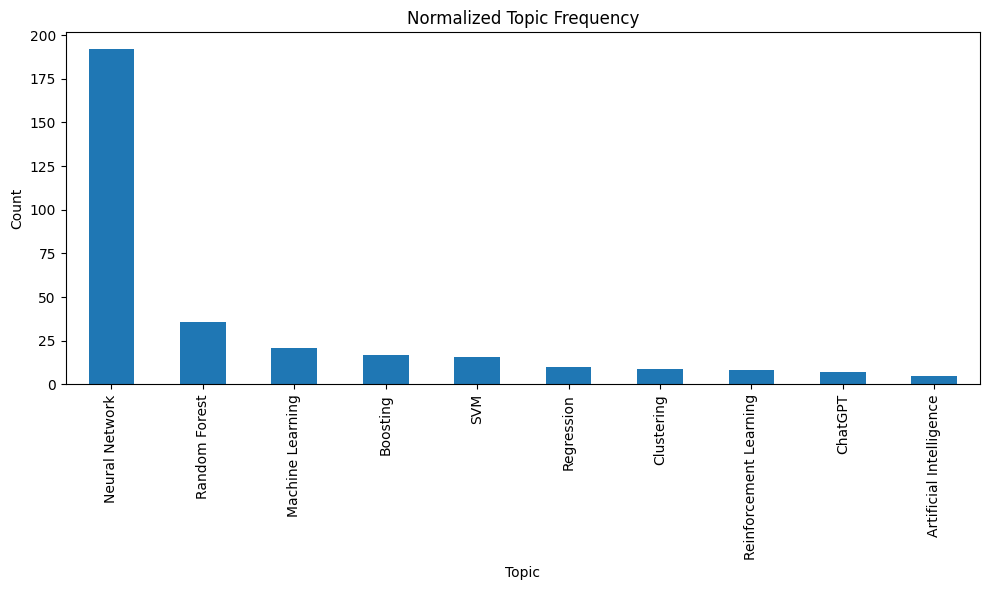

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
topic_counts[:10].plot(kind="bar")
plt.title("Normalized Topic Frequency")
plt.ylabel("Count")
plt.xlabel("Topic")
plt.tight_layout()
plt.show()


In [ ]:
funding_counts = matches_df["fund"].value_counts()

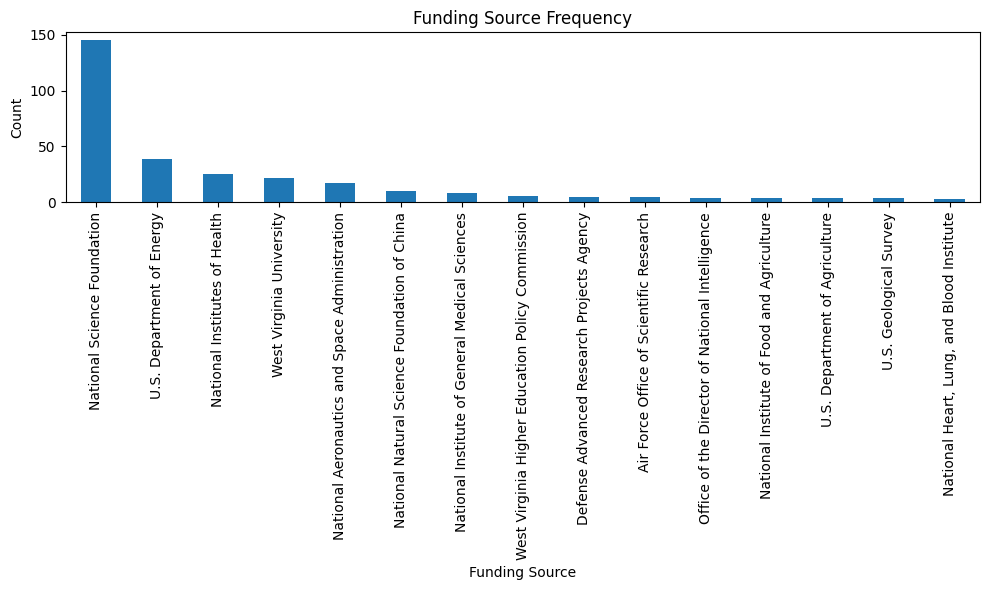

In [ ]:
funding_counts = matches_df["fund_sponsor"].value_counts()
plt.figure(figsize=(10,6))
funding_counts[:15].plot(kind="bar")
plt.title("Funding Source Frequency")
plt.ylabel("Count")
plt.xlabel("Funding Source")
plt.tight_layout()
plt.show()

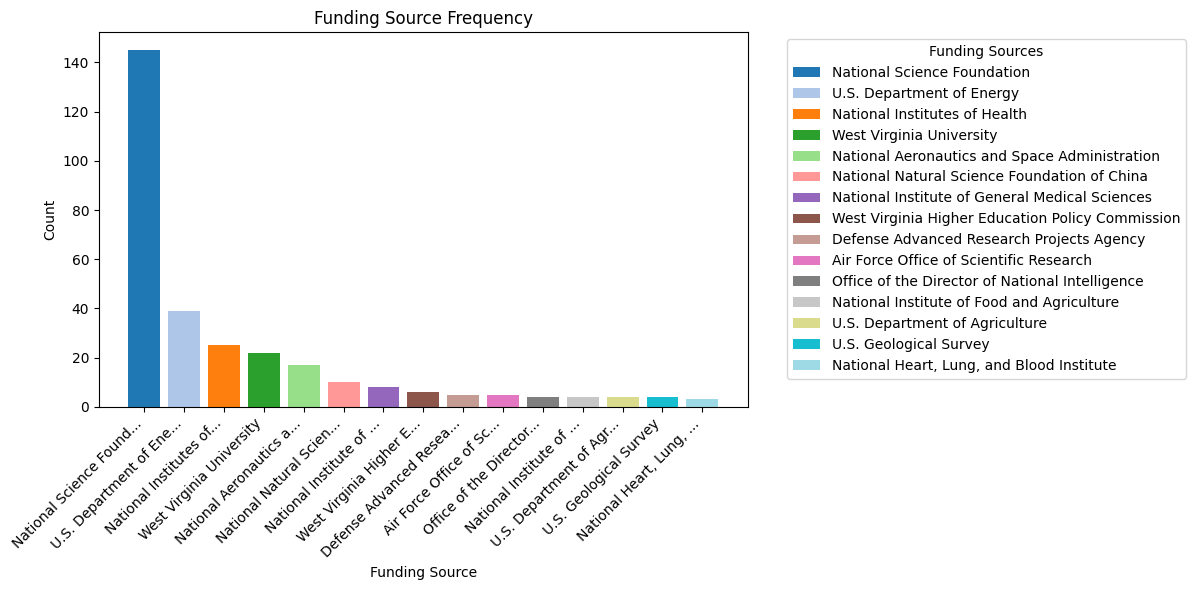

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

funding_counts = matches_df["fund_sponsor"].value_counts()
top15 = funding_counts[:15]

plt.figure(figsize=(12,6))

# Distinct colors for each bar
colors = plt.cm.tab20(np.linspace(0, 1, len(top15)))

bars = plt.bar(range(len(top15)), top15.values, color=colors)

plt.title("Funding Source Frequency")
plt.ylabel("Count")
plt.xlabel("Funding Source")

# Rotate long labels & shorten if too long
labels = [lbl if len(lbl) < 25 else lbl[:22] + "..." for lbl in top15.index]
plt.xticks(range(len(top15)), labels, rotation=45, ha="right")

# Add legend (key)
plt.legend(bars, top15.index, title="Funding Sources", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()
